# Previsão de Preços de Imóveis

Versão simplificada do projeto original. Mesma base de dados, refeita com o approach que eu uso hoje, tratamento mais enxuto, regressão linear com alvo em log e validação cruzada (K-Fold)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, roc_auc_score

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Carregamento e tratamento

In [ ]:
df = pd.read_csv('house_sales.csv')
print(df.shape)
df.isnull().sum().sum()

(18448, 16)


np.int64(0)

In [ ]:
# renovation_date = 0 quando nunca foi reformado, vira flag binária
df['is_renovated'] = (df['renovation_date'] > 0).astype(int)

# zip como número não carrega ordem nenhuma, lat/long já cobrem localização
df = df.drop(columns=['renovation_date', 'zip'])

df[['price', 'size_house', 'year_built']].describe()

,price,size_house,year_built
count,"18,448.00","18,448.00","18,448.00"
mean,"542,362.37","2,083.94","1,971.00"
std,"372,013.52",921.42,29.36
min,"78,000.00",290.00,"1,900.00"
25%,"321,837.50","1,430.00","1,952.00"
50%,"450,000.00","1,920.00","1,975.00"
75%,"648,000.00","2,560.00","1,997.00"
max,"7,700,000.00","13,540.00","2,015.00"


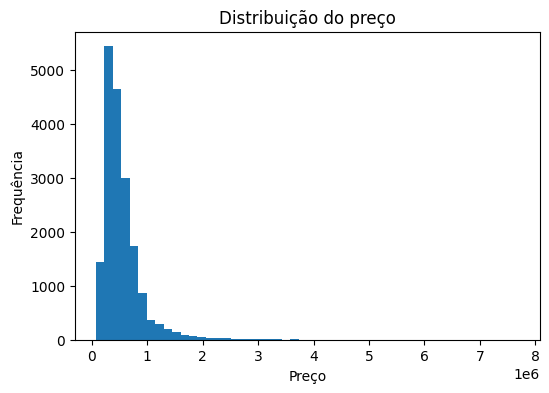

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df['price'], bins=50)
plt.title('Distribuição do preço')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

Preço de imóvel sempre tem aquela assimetria comum para a época (muito imóvel barato e poucos absurdamente caros). Por isso testo o modelo tanto no preço bruto quanto no log, log ajuda a desentortar a distribuição e melhora o ajuste.

## Separação treino/teste

In [ ]:
features = ['num_bed', 'num_bath', 'size_house', 'size_lot', 'num_floors',
            'is_waterfront', 'condition', 'size_basement', 'year_built',
            'is_renovated', 'latitude', 'longitude',
            'avg_size_neighbor_houses', 'avg_size_neighbor_lot']

X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((14758, 14), (3690, 14))

## Regressão linear

In [ ]:
def report(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:<22} RMSE: {rmse:>12,.0f}  MAE: {mae:>12,.0f}  R2: {r2:.3f}')
    return rmse, mae, r2

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

_ = report(y_test, pred, 'Linear (preço bruto)')

Linear (preço bruto)   RMSE:      224,902  MAE:      137,834  R2: 0.650


In [ ]:
y_train_log = np.log1p(y_train)

lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)

pred_log = lr_log.predict(X_test)
pred_log_original = np.expm1(pred_log)

_ = report(y_test, pred_log_original, 'Linear (log-preço)')

Linear (log-preço)     RMSE:      201,482  MAE:      122,784  R2: 0.719


Log ganha nas duas métricas. É o modelo que eu levo pra frente daqui pra baixo.

## Validação cruzada (5-fold)

In [ ]:
y_log_full = np.log1p(y)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(lr_log, X, y_log_full, cv=kf, scoring='r2')
rmse_scores = -cross_val_score(lr_log, X, y_log_full, cv=kf, scoring='neg_root_mean_squared_error')

print('R2 por fold:      ', np.round(r2_scores, 3))
print(f'R2 médio:          {r2_scores.mean():.3f} (+/- {r2_scores.std():.3f})')
print('RMSE (log) por fold:', np.round(rmse_scores, 3))
print(f'RMSE (log) médio:   {rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f})')

R2 por fold:       [0.727 0.716 0.738 0.724 0.716]
R2 médio:          0.724 (+/- 0.008)
RMSE (log) por fold: [0.28  0.276 0.278 0.275 0.28 ]
RMSE (log) médio:   0.278 (+/- 0.002)


## Previsto vs real

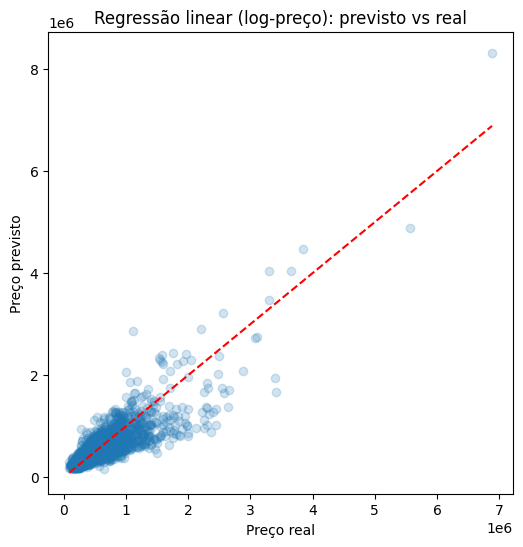

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_log_original, alpha=0.2)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color='red', linestyle='--')
plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.title('Regressão linear (log-preço): previsto vs real')
plt.show()

## Conclusão

Nesta revisão, priorizei um pipeline limpo e focado na entrega de uma baseline sólida de regressão linear. Foram removidas complexidades que não geravam valor (como tratar CEP como variável numérica ou over-engineering em polinomiais) para focar na modelagem:

* **Target em Log:** A transformação corrigiu a assimetria do preço, entregando métricas melhores (RMSE e R²) comparado ao modelo treinado no preço bruto.
* **Validação Robusta:** O uso de validação cruzada (K-Fold) garante que a performance reportada é generalizável e não um artefato de um split de dados específico.